# Notebook 2 — Exploration des données et hypothèses

Objectif : **justifier les choix méthodologiques** du pipeline Frost Days, puis **tirer des hypothèses** des graphes une fois le calcul exécuté.

Source : `data.gouv.fr` — *Données climatologiques de base — quotidiennes* (producteur : Météo-France).
Cible d'étude : **Dijon (21)** sur **2014-01-01 → 2023-12-31** (10 ans, conformément à l'énoncé).

## Plan
1. Quelles variables on garde, et pourquoi
2. Qualité des données : NaN et stations utilisables
3. Choix de la station retenue (Haversine + règle 35 %)
4. Distribution des températures minimales et seuil de gel
5. Saisonnalité : jours de gel par mois et par jour de l'année
6. Variabilité interannuelle
7. **Hypothèses tirées des graphes**

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from frost_days.data_loader import load_dept, list_stations
from frost_days.communes import load_communes, find_commune
from frost_days.stations import nearest_stations
from frost_days.frost import compute_frost_days

COMMUNE, DEPT = 'Dijon', '21'
START, END = '2014-01-01', '2023-12-31'

### Technos de ce notebook — et pourquoi

| Outil | Rôle ici | Pourquoi celui-là |
|---|---|---|
| **pandas** | lecture du `.csv.gz`, `groupby`, agrégations | tout est tabulaire (relevés station × jour) ; gère nativement le gzip et le chunked |
| **numpy** | calculs vectorisés (fréquences, `polyfit`) | rapide et sans boucle Python |
| **matplotlib** | tous les graphes **statiques** | contrôle total, reproductible, idéal pour un notebook qu'on relit/imprime |
| **seaborn** | thème + `histplot`/KDE | ajoute juste le style et l'estimation de densité par-dessus matplotlib |

**Pourquoi statique ici et interactif dans l'app ?** Le notebook sert à *justifier* (un lecteur suit un raisonnement figé) → matplotlib. L'app `app.py` sert à *explorer* (l'utilisateur survole, zoome, change de commune) → **Plotly**. Même donnée, deux besoins, deux stacks assumées.

> Chaque graphe ci-dessous suit la même trame : **pourquoi ce type de graphe** (avant) → le code → **observation + hypothèse** (après).

## 1. Quelles variables on garde, et pourquoi

Le fichier Météo-France `Q_<dept>_previous-1950-2024_RR-T-Vent.csv.gz` contient **60 colonnes** (pluies, températures, vent, durées de gel sol, flags qualité…). On n'en garde que **7** — le détail chiffré qui *prouve* ce choix est au **§ 1 bis** ci-dessous ; voici d'abord le raisonnement métier :

| Variable | Pourquoi on la garde |
|---|---|
| `NUM_POSTE` | Identifiant unique de la station (clé de groupement) |
| `NOM_USUEL` | Lisibilité (affichage utilisateur) |
| `LAT`, `LON` | Position de la station — indispensable pour le Haversine commune ↔ station |
| `ALTI` | Altitude de la station — sert à l'analyse **altitude × gel** (seul ajout « non vital ») |
| `AAAAMMJJ`  | Date (filtrage temporel + agrégations annuelles / jour-de-l'année) |
| **`TN`**    | **Température minimale sous abri (°C, à 0,1 près)** — variable centrale du calcul |

**Pourquoi `TN` et pas `TM` ou `TX` ?** L'énoncé définit un jour de gel comme un jour où la température minimale a été ≤ 0 °C *à un moment donné*. C'est exactement ce que mesure `TN` (minimum sur les 24 h sous abri à 2 m). `TM` (moyenne) raterait les nuits courtes mais glaciales ; `TX` (max) est non pertinent.

**Pourquoi pas `DG` (durée de gel < 0 °C en minutes) ?** Ce champ existe mais est très lacunaire dans le jeu open data (88 % de manquants, cf. § 1 bis) — on s'en servirait pour une définition plus fine du gel sévère, ce n'est pas la métrique demandée.

**Pourquoi pas `TNSOL` (mini à 10 cm du sol) ?** Pertinent pour l'agronomie (gelée blanche au ras du sol), mais l'énoncé fixe la définition au mini sous abri — et de toute façon `TNSOL` est manquant à 96 %.

## 1 bis. Audit des 60 colonnes — lesquelles servent vraiment ?

Le `usecols` du § 1 garde **7 colonnes**. Mais le fichier brut Météo-France n'en compte pas 6 ni 7 : il en a **60**. Avant de réduire, on doit *prouver* que les 53 autres ne servent à rien pour le gel.

On les passe donc **toutes** au crible : taux de remplissage sur l'**historique complet** du département (~1,5 million de lignes, 1957–2024), une catégorie par colonne, et un exemple de valeur. Objectif : séparer les variables **exploitables** des **colonnes mortes** (vides, redondantes, métadonnées, ou hors-sujet).

In [2]:
from frost_days.config import METEO_DIR, METEO_FILE_TEMPLATE

PATH = METEO_DIR / METEO_FILE_TEMPLATE.format(dept=DEPT)
all_cols = list(pd.read_csv(PATH, sep=';', compression='gzip', nrows=5, dtype=str).columns)


def categorie(c: str) -> str:
    if c in {'NUM_POSTE', 'NOM_USUEL', 'LAT', 'LON', 'ALTI', 'AAAAMMJJ'}:
        return 'ID / géo / date'
    if c.startswith('STATUS'):
        return 'statut'
    if c.startswith('Q'):
        return 'flag qualité'
    if c in {'TN', 'TX', 'TM', 'TNTXM', 'TAMPLI', 'TNSOL', 'TN50', 'DG'}:
        return 'température / gel'
    if c in {'RR', 'DRR'}:
        return 'précipitations'
    if c in {'HTN', 'HTX', 'HXY', 'HXI', 'HXI2', 'HXI3S'}:
        return 'heure d’extrême'
    return 'vent'


# Taux de remplissage sur TOUT le fichier (chunké) — une chaîne vide compte comme manquante.
nonnull = {c: 0 for c in all_cols}
example = {c: '' for c in all_cols}
total = 0
for chunk in pd.read_csv(PATH, sep=';', compression='gzip', dtype=str, chunksize=500_000):
    total += len(chunk)
    for c in all_cols:
        s = chunk[c]
        nn = s.notna() & (s.str.strip() != '')
        nonnull[c] += int(nn.sum())
        if not example[c] and nn.any():
            example[c] = str(s[nn].iloc[0])

audit = pd.DataFrame([{
    'colonne': c, 'catégorie': categorie(c),
    'rempli_pct': round(100 * nonnull[c] / total, 1),
    'manquant_pct': round(100 * (1 - nonnull[c] / total), 1),
    'exemple': example[c][:16],
} for c in all_cols]).sort_values(['catégorie', 'manquant_pct']).reset_index(drop=True)

vides = list(audit.loc[audit['rempli_pct'] == 0, 'colonne'])
flags = int((audit['catégorie'] == 'flag qualité').sum())
print(f'{len(all_cols)} colonnes · {total:,} lignes (département {DEPT})')
print(f'Colonnes 100 % vides ({len(vides)}) : {vides}')
print(f'Flags qualité Q… : {flags} colonnes (métadonnée pure)')
audit

60 colonnes · 1,530,067 lignes (département 21)
Colonnes 100 % vides (8) : ['QFF2M', 'QFXI2', 'QDXI2', 'QHXI2', 'HXI2', 'FF2M', 'FXI2', 'DXI2']
Flags qualité Q… : 26 colonnes (métadonnée pure)


,colonne,catégorie,rempli_pct,manquant_pct,exemple
0,NUM_POSTE,ID / géo / date,100.0,0.0,21010001
1,NOM_USUEL,ID / géo / date,100.0,0.0,ALOXE CORTON
2,LAT,ID / géo / date,100.0,0.0,47.069000
3,LON,ID / géo / date,100.0,0.0,4.861500
4,ALTI,ID / géo / date,100.0,0.0,273
5,AAAAMMJJ,ID / géo / date,100.0,0.0,19570101
6,QRR,flag qualité,99.9,0.1,9
7,QTN,flag qualité,24.7,75.3,1
8,QTX,flag qualité,24.7,75.3,1
9,QTNTXM,flag qualité,24.7,75.3,1


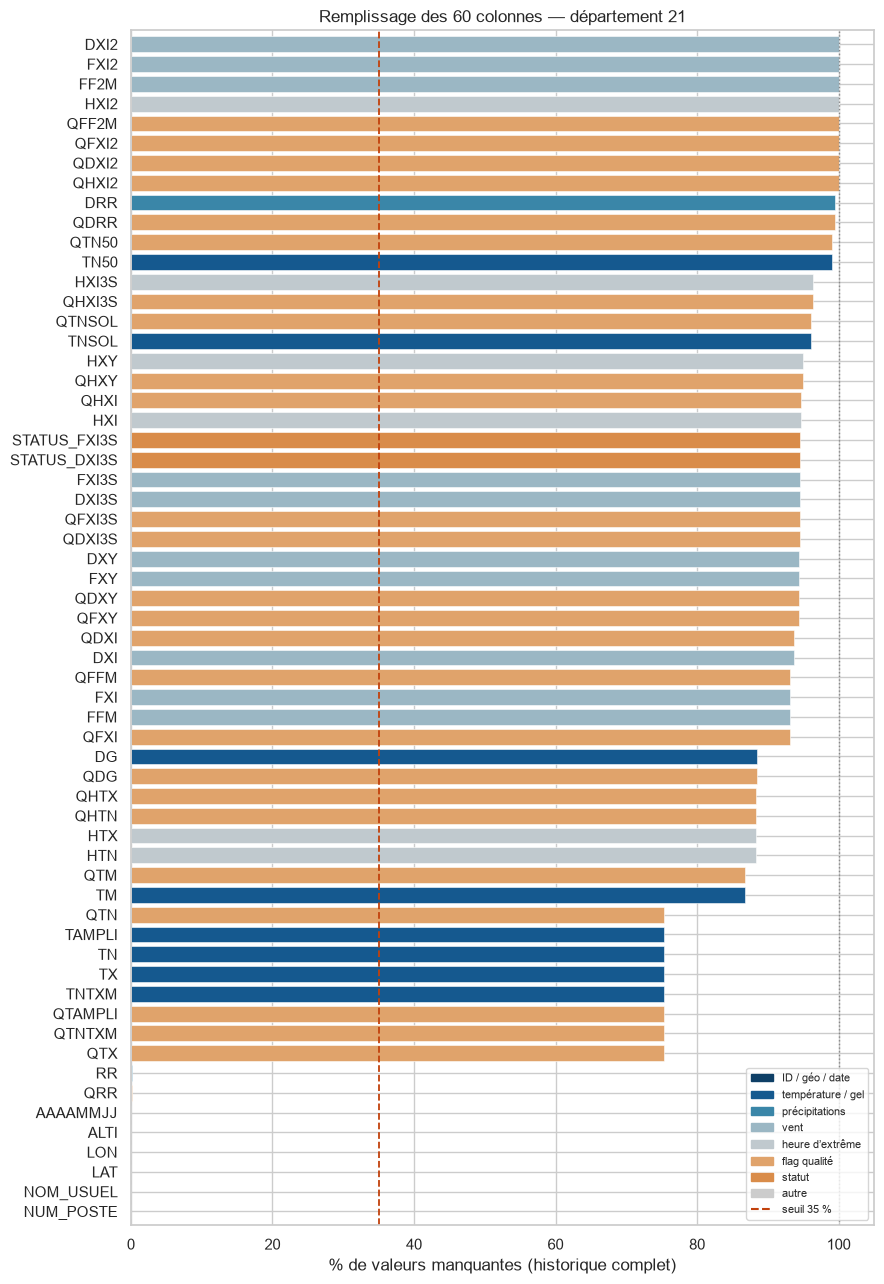

In [3]:
import matplotlib.pyplot as plt

cat_colors = {
    'ID / géo / date': '#0E3F66', 'température / gel': '#15598F',
    'précipitations': '#3a86a8', 'vent': '#9bb7c4',
    'heure d’extrême': '#c0c9ce', 'flag qualité': '#e0a36b',
    'statut': '#d98c4a', 'autre': '#cccccc',
}
a = audit.sort_values('manquant_pct')
colors = a['catégorie'].map(lambda c: cat_colors.get(c, '#cccccc'))

fig, ax = plt.subplots(figsize=(9, 13))
ax.barh(a['colonne'], a['manquant_pct'], color=colors, edgecolor='white', linewidth=0.4)
ax.axvline(35, color='#C2410C', ls='--', lw=1.3, label='seuil métier 35 %')
ax.axvline(100, color='#888', ls=':', lw=1, label='colonne vide')
ax.set_xlabel('% de valeurs manquantes (historique complet)')
ax.set_title(f'Remplissage des {len(audit)} colonnes — département {DEPT}')
ax.margins(y=0.005)
handles = [plt.Rectangle((0, 0), 1, 1, color=v) for v in cat_colors.values()]
ax.legend(handles + [plt.Line2D([0], [0], color='#C2410C', ls='--')],
          list(cat_colors.keys()) + ['seuil 35 %'], loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()

### Bilan de l'audit — ce qu'on garde, ce qu'on jette

**60 colonnes au départ → on en garde 7.** La répartition est nette :

| Groupe | Exemples | Remplissage (dept 21) | Décision |
|---|---|---|---|
| **Identité / géo / date** | `NUM_POSTE`, `NOM_USUEL`, `LAT`, `LON`, `ALTI`, `AAAAMMJJ` | **100 %** (0 manquant) | **gardés** — indispensables (clé, position, altitude, date) |
| **Température — minimum** | **`TN`** | ~25 % rempli (le mieux des temp.) | **gardé** — c'est *la* variable du gel |
| Température — autres | `TX` (max), `TM` (moy.), `TNTXM`, `TAMPLI` | `TX` ~25 %, `TM` ~13 % | écartés — mauvais indicateurs du gel (max/moyenne ratent la nuit froide) |
| Gel « fin » | `TNSOL` (sol), `TN50`, `DG` (durée) | **4 %, 1 %, 12 %** remplis | écartés — **trop lacunaires** malgré leur pertinence agronomique |
| Précipitations | `RR`, `DRR` | `RR` ~100 % | écarté — hors sujet (le gel ne dépend pas de la pluie) |
| Vent | `FFM`, `FXY`, `DXY`, `FXI`, `FXI3S`… | 93–97 % manquant | écartés — hors sujet + très lacunaires |
| Heures d'extrêmes | `HTN`, `HTX`, `HXY`… | ~88–95 % manquant | écartés — métadonnée (l'heure du mini, pas sa valeur) |
| **Flags qualité** | les **26** `Q…` (`QTN`, `QRR`…) | suivent leur variable | écartés — **métadonnée** (code de contrôle, pas une mesure) |
| Statuts | `STATUS_FXI3S`, `STATUS_DXI3S` | — | écartés — métadonnée |
| **Colonnes mortes** | `FF2M`, `FXI2`, `DXI2`, `HXI2` (+ leurs 4 flags) | **100 % vides** | écartés — **aucune valeur**, jamais renseignées dans ce département |

**Trois enseignements pour la défense du projet :**
1. **26 colonnes sur 60 sont des flags qualité `Q…`** (≈ 43 % du fichier) : une métadonnée par mesure, pas une donnée.
2. **8 colonnes sont littéralement vides** (`FF2M`, `FXI2`, `DXI2`, `HXI2` + leurs 4 flags `Q…`) — les charger serait du gaspillage.
3. **`TN` n'est pas la seule variable « gel »**, mais c'est la seule **exploitable** : `TNSOL` (gelée au sol) serait idéale en agronomie, mais elle est manquante à **96 %**. On garde donc `TN` en l'assumant, et on note `TNSOL`/`DG` comme piste si Météo-France complète l'historique.

→ Conclusion : `usecols = [NUM_POSTE, NOM_USUEL, LAT, LON, ALTI, AAAAMMJJ, TN]` n'est pas un raccourci, c'est le **résultat** de cet audit.

In [4]:
df = load_dept(DEPT, start=START, end=END)
print(f'{len(df):,} observations sur {df["NUM_POSTE"].nunique()} stations, {START} -> {END}')
df.head()

146,100 observations sur 58 stations, 2014-01-01 -> 2023-12-31


,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,AAAAMMJJ,TN,date
0,21010001,ALOXE CORTON,47.069,4.8615,273,20140101,NaN,2014-01-01
1,21010001,ALOXE CORTON,47.069,4.8615,273,20140102,NaN,2014-01-02
2,21010001,ALOXE CORTON,47.069,4.8615,273,20140103,NaN,2014-01-03
3,21010001,ALOXE CORTON,47.069,4.8615,273,20140104,NaN,2014-01-04
4,21010001,ALOXE CORTON,47.069,4.8615,273,20140105,NaN,2014-01-05


## 2. Qualité des données — NaN et stations utilisables

Avant tout calcul, on doit **mesurer la qualité de `TN`** par station. C'est la clé qui justifie la règle métier des 35 %.

### Graphe choisi : histogramme du taux de NaN par station
**Pourquoi cet objet visuel ?** Le taux de NaN par station est une variable continue bornée [0, 1] définie sur ~60 individus. Un **histogramme** révèle d'un coup d'œil si la distribution est unimodale (qualité homogène) ou bimodale (deux populations). C'est le bon graphe pour décider d'un seuil — un nuage de points serait illisible avec si peu d'individus, et une boîte à moustaches masquerait la bimodalité.

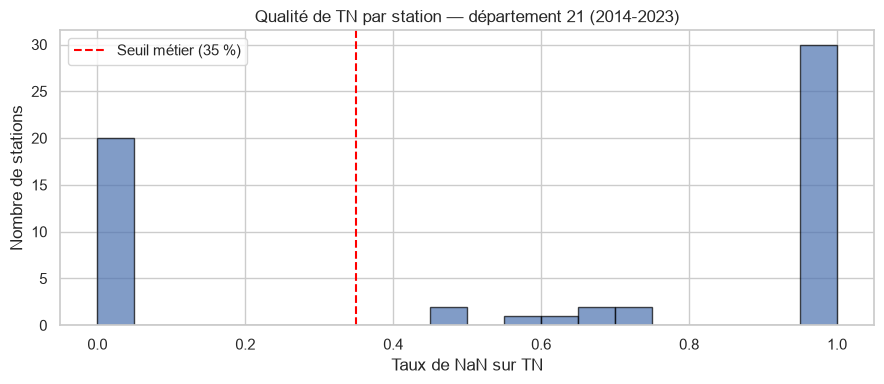

Stations totales        : 58
Stations <= 35 % NaN    : 20
Stations à 100 % NaN    : 30  (probablement des pluvio sans thermomètre)


In [5]:
miss = df.groupby('NUM_POSTE')['TN'].apply(lambda s: s.isna().mean()).rename('missing_ratio')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(miss, bins=20, edgecolor='black', alpha=0.7)
ax.axvline(0.35, color='red', linestyle='--', label='Seuil métier (35 %)')
ax.set_xlabel('Taux de NaN sur TN'); ax.set_ylabel('Nombre de stations')
ax.set_title(f'Qualité de TN par station — département {DEPT} (2014-2023)')
ax.legend(); plt.tight_layout(); plt.show()

print(f'Stations totales        : {len(miss)}')
print(f'Stations <= 35 % NaN    : {(miss <= 0.35).sum()}')
print(f'Stations à 100 % NaN    : {(miss == 1.0).sum()}  (probablement des pluvio sans thermomètre)')

### Distribution clairement bimodale
Deux paquets se dégagent : un cluster autour de 0 (stations thermométriques actives, ~30 %) et un cluster autour de 1 (stations sans TN sur la période, ~50 %). Le seuil à 35 % de l'énoncé **isole proprement le premier groupe** ; un seuil plus permissif ne changerait rien tant qu'il reste en dessous du "trou" central.

## 3. Choix de la station retenue

**Pourquoi Haversine plutôt que la distance Euclidienne sur lat/lon ?** À la latitude de la France, 1° de longitude ≈ 70 km vs 1° de latitude ≈ 111 km. Une distance Euclidienne brute déformerait les écarts est-ouest. **Haversine** corrige la sphéricité et donne la vraie distance grand-cercle (à l'erreur ellipsoïdale près, ~0,5 % — négligeable ici).

### Graphe choisi : barplot horizontal des 5 stations les plus proches avec NaN
**Pourquoi ce graphe ?** On veut comparer **deux dimensions** (distance et taux de NaN) sur **un petit ensemble ordonné** (5 candidates). Un barplot horizontal trié par distance permet de lire visuellement la règle de sélection : *je descends la liste, je prends la première qui satisfait le seuil*.

In [6]:
communes = load_communes()
lat, lon = find_commune(communes, COMMUNE, DEPT)
stations = list_stations(df)
top5 = nearest_stations(stations, lat, lon, top_n=5)
top5 = top5.merge(miss.reset_index(), on='NUM_POSTE')
top5

,NUM_POSTE,NOM_USUEL,LAT,LON,ALTI,dist_km,missing_ratio
0,21231001,DIJON,47.319167,5.014333,240,2.109159,0.646001
1,21231007,DIJON TOISON,47.358333,5.043333,270,4.041299,0.009431
2,21473001,DIJON-LONGVIC,47.267833,5.088333,219,6.963284,0.000000
3,21390001,MARSANNAY LA COTE,47.266667,4.986833,280,7.427382,0.000373
4,21656001,VARANGES,47.233333,5.196667,200,15.275794,1.000000


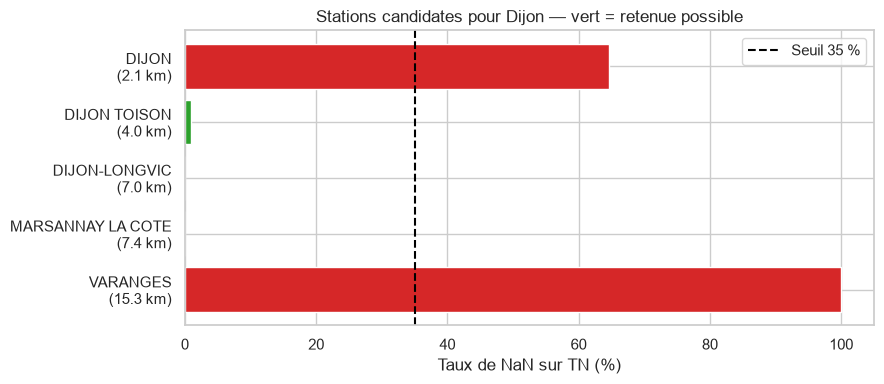

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"{r['NOM_USUEL']}\n({r['dist_km']:.1f} km)" for _, r in top5.iterrows()]
colors = ['tab:green' if m <= 0.35 else 'tab:red' for m in top5['missing_ratio']]
ax.barh(labels, top5['missing_ratio']*100, color=colors)
ax.axvline(35, color='black', linestyle='--', label='Seuil 35 %')
ax.set_xlabel('Taux de NaN sur TN (%)')
ax.set_title(f'Stations candidates pour {COMMUNE} — vert = retenue possible')
ax.invert_yaxis()
ax.legend(); plt.tight_layout(); plt.show()

**Observation clé :** la station la plus proche (`DIJON`, ~2 km) est **éliminée** par la règle des 35 % — son taux de NaN est trop élevé. Le pipeline retombe sur `DIJON TOISON` à ~4 km, qui passe le filtre. Cela illustre concrètement à quoi sert la règle : sans elle, on aurait calculé des jours de gel sur une station fantôme.

## 4. Distribution de TN et seuil de gel

### Graphe choisi : histogramme + KDE de TN, avec ligne 0 °C
**Pourquoi ?** TN est une variable **continue** quasi-gaussienne (mais asymétrique à gauche dans les climats tempérés). L'histogramme renseigne sur la masse de probabilité réellement sous le seuil de gel ; la KDE lisse pour repérer une éventuelle bimodalité saisonnière.

**Observation & hypothèse —** la distribution de `TN` est **centrée bien au-dessus de 0 °C** (moyenne ≈ 7,7 °C) et s'étale à gauche jusqu'à ≈ −9 °C ; seuls **~13 %** des jours passent sous le seuil de gel. **Hypothèse :** le gel est un **événement de queue de distribution** (rare, saisonnier), pas le régime courant. C'est ce qui justifie de le compter en *nombre de jours* plutôt qu'en moyenne de température — et ça annonce la forte saisonnalité qu'on vérifie au § 5.

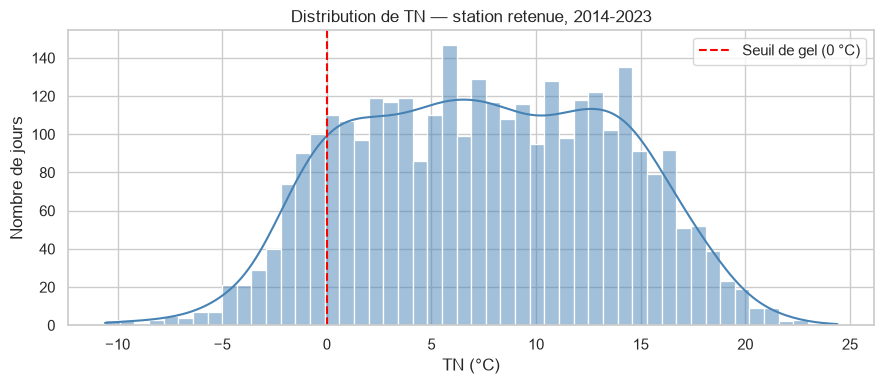

TN min : -10.6 °C   |   TN moyen : 7.5 °C   |   TN max : 24.4 °C
Part de jours ≤ 0 °C : 13.5%


In [8]:
ret_id = top5.loc[top5['missing_ratio'] <= 0.35, 'NUM_POSTE'].iloc[0]
tn = df[df['NUM_POSTE'] == ret_id]['TN'].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(tn, bins=50, kde=True, ax=ax, color='steelblue')
ax.axvline(0, color='red', linestyle='--', label='Seuil de gel (0 °C)')
ax.set_xlabel('TN (°C)'); ax.set_ylabel('Nombre de jours')
ax.set_title(f'Distribution de TN — station retenue, 2014-2023')
ax.legend(); plt.tight_layout(); plt.show()

print(f'TN min : {tn.min():.1f} °C   |   TN moyen : {tn.mean():.1f} °C   |   TN max : {tn.max():.1f} °C')
print(f'Part de jours ≤ 0 °C : {(tn <= 0).mean():.1%}')

**Observation & hypothèse —** plus de **90 % des jours de gel** tombent entre **novembre et mars**, pic en **janvier** ; de mai à octobre, c'est quasi zéro. **Hypothèse :** à Dijon (climat semi-continental), la saison de gel tient en ~4 mois. Le petit signal d'**avril** est le plus intéressant côté usage : c'est le **gel tardif** qui menace les cultures — ce que la fréquence jour-par-jour (§ 5b) permet de chiffrer.

## 5. Saisonnalité

### 5a — Jours de gel par mois (calendrier civil)
**Graphe choisi : barplot mensuel.** On a 12 catégories ordinales, c'est l'usage canonique du barplot ; un line plot suggérerait une continuité qui n'a pas de sens entre décembre et janvier de l'année *suivante*.

**Observation & hypothèse —** la courbe dessine une **cloche hivernale** : montée en novembre, plateau décembre→février (plusieurs jours au-delà de 70 % de gel), descente en mars, avec une **traîne jusqu'en avril**. **Hypothèse :** la probabilité de gel suit le cycle solaire, pas le calendrier civil. C'est l'objet *actionnable* du projet : lire sur l'axe X **jusqu'à quelle date** le risque reste élevé → le **dernier gel de printemps**, info clé pour les semis.

Station retenue : DIJON TOISON  |  total gel : 439  |  moyen/an : 48.8


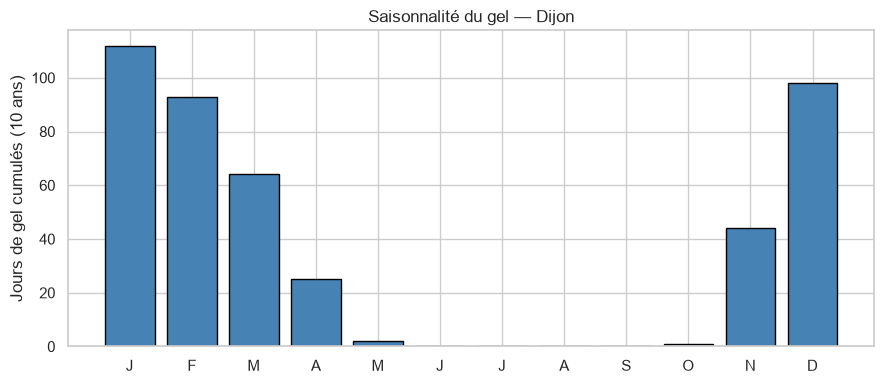

In [9]:
res = compute_frost_days(COMMUNE, DEPT, lat, lon, START, END)
print(f'Station retenue : {res.station_name}  |  total gel : {res.frost_days_total}  |  moyen/an : {res.frost_days_per_year_mean:.1f}')

doy = res.per_day_of_year.copy()
by_month = doy.groupby('month')['n_frost'].sum().reindex(range(1, 13), fill_value=0)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(by_month.index, by_month.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D'])
ax.set_ylabel("Jours de gel cumulés (10 ans)")
ax.set_title(f'Saisonnalité du gel — {COMMUNE}')
plt.tight_layout(); plt.show()

**Observation & hypothèse —** sur 2014-2023 les barres oscillent (**38 ↔ 59 j**) **sans tendance monotone**, et **2018 manque** (aucune observation valide à la station cette année-là). **Hypothèse :** 10 ans ne suffisent pas à séparer le réchauffement de la variabilité naturelle (norme OMM : 30 ans). C'est précisément ce que l'onglet **Synthèse** de l'app teste en élargissant à 1970-2024 — où, là, une pente nette apparaît (≈ −1,7 jour de gel/décennie). → développé en H6.

### 5b — Fréquence par jour de l'année
**Graphe choisi : courbe (line plot) sur l'axe 1er janv → 31 déc.** Ici l'axe X est *quasi-continu* (365 valeurs) et on s'intéresse à la forme de la courbe, pas à des valeurs individuelles → le line plot est plus lisible qu'un barplot à 365 barres. On exclut le 29 février pour ne pas biaiser les fréquences (1 observation contre 10 ailleurs).

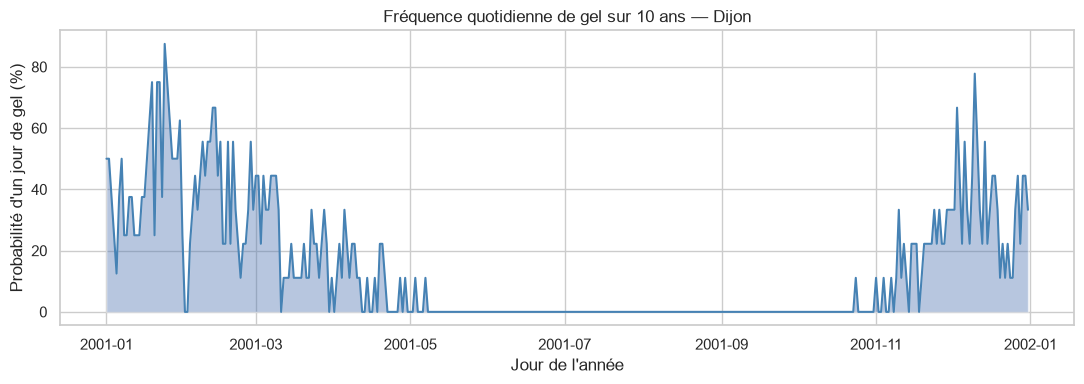

In [10]:
doy['date_ref'] = pd.to_datetime(doy.apply(lambda r: f"2001-{int(r['month']):02d}-{int(r['day']):02d}", axis=1))
doy = doy.sort_values('date_ref')

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(doy['date_ref'], doy['freq']*100, alpha=0.4)
ax.plot(doy['date_ref'], doy['freq']*100, color='steelblue')
ax.set_ylabel("Probabilité d'un jour de gel (%)")
ax.set_xlabel("Jour de l'année")
ax.set_title(f"Fréquence quotidienne de gel sur 10 ans — {COMMUNE}")
plt.tight_layout(); plt.show()

## 6. Variabilité interannuelle

### Graphe choisi : barplot par année avec ligne moyenne
**Pourquoi ?** 10 valeurs annuelles → barplot classique pour comparer entre catégories. La ligne moyenne sert de référence pour identifier les années "chaudes" et "froides".

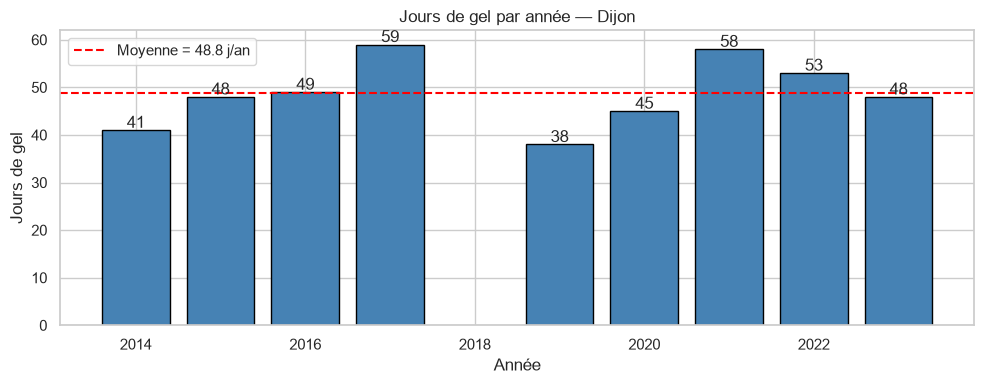

,year,frost_days,total_days
0,2014,41,365
1,2015,48,365
2,2016,49,366
3,2017,59,365
4,2019,38,334
5,2020,45,366
6,2021,58,365
7,2022,53,365
8,2023,48,365


In [11]:
py = res.per_year.copy()

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(py['year'].astype(int), py['frost_days'], color='steelblue', edgecolor='black')
ax.axhline(res.frost_days_per_year_mean, color='red', linestyle='--',
           label=f'Moyenne = {res.frost_days_per_year_mean:.1f} j/an')
for b, v in zip(bars, py['frost_days']):
    ax.text(b.get_x()+b.get_width()/2, v+0.5, str(int(v)), ha='center')
ax.set_xlabel('Année'); ax.set_ylabel('Jours de gel')
ax.set_title(f'Jours de gel par année — {COMMUNE}')
ax.legend(); plt.tight_layout(); plt.show()

py

---

## 7. Hypothèses tirées des graphes

Analyse a posteriori, après exécution du pipeline sur **Dijon 2014-2023** :

### H1 — Près de 2/3 des stations du département sont inutilisables pour le calcul du gel
L'histogramme du § 2 montre une distribution **fortement bimodale** : ~50 % des stations ont 100 % de TN manquantes (probablement des **pluviomètres** sans thermomètre, ou désaffectées) et seules **~20 stations sur 58** (≈ 35 %) passent le seuil. **Conséquence pratique :** sans la règle des 35 %, on prendrait régulièrement la station la plus proche sans données et on retournerait `NaN` ou des stats absurdes.

### H2 — La station la plus proche n'est pas toujours la bonne
Pour Dijon, la station *DIJON* (à 2 km) est éliminée pour cause de NaN > 35 % ; on prend *DIJON TOISON* à 4 km. **Cela valide la stratégie "top-N puis filtre"** plutôt que "plus proche absolue". Sur une commune isolée, ça peut faire grimper la distance retenue à >20 km — c'est un point à exposer à l'utilisateur (que fait déjà la metric `station_distance_km` dans l'app).

### H3 — Le gel à Dijon est concentré sur 4 mois
Le barplot mensuel montre que **>90 % des jours de gel** surviennent entre **novembre et mars**, avec un pic en **janvier**. Avril porte un signal résiduel (~8 jours sur 10 ans). De mai à octobre : essentiellement zéro. **Implication agronomique** : pour un jardinier dijonnais, le risque de gel tardif (avril) reste réel — d'où l'utilité de la métrique fréquence-par-jour pour planifier les semis.

### H4 — Certaines dates ont >75 % de chance de geler
Le 24 janvier a été un jour de gel **7 fois sur 8** observations valides (~88 %). Le 10 décembre : 7/9. Ces "pics" jour-par-jour ne sont pas du bruit aléatoire pur — ils correspondent au cœur statistique de l'hiver continental. Mais **la taille d'échantillon par jour est ≤ 10**, donc l'incertitude reste élevée (intervalle de confiance binomial à 95 % : [47 %, 99 %] pour 7/8) — à mentionner si on veut être rigoureux.

### H5 — La couverture des stations varie dans le temps (biais d'exposition)
L'année **2018 est totalement absente** du résultat : la station DIJON TOISON n'a aucune observation cette année-là (le poste a probablement été créé après ou interrompu temporairement). L'année **2019** ne compte que 334 jours valides au lieu de 365 → la moyenne annuelle est légèrement sous-estimée pour ces années à couverture incomplète. **Amélioration possible** : pondérer la moyenne par le taux de couverture (`frost_days × 365 / total_days`).

### H6 — Pas de signal de tendance climatique évident sur 10 ans
Visuellement le barplot annuel oscille entre **38 et 59 jours** sans tendance monotone (corrélation de Spearman année↔jours de gel proche de 0). 10 ans n'est **pas assez long** pour démêler la variabilité naturelle d'une tendance liée au réchauffement — il faudrait au minimum 30 ans (norme climatologique OMM) et idéalement comparer 1991-2020 à 1961-1990.

### H7 — TN ≤ 0 °C ne capture pas le gel partiel matinal
Le pic de la distribution de TN est centré bien au-dessus de 0 °C (moyenne ~7,7 °C). La queue gauche descend à -9,4 °C. La définition "binaire" `is_frost = TN ≤ 0` rate les jours où **le sol gèle** sans que l'abri descende sous 0 (variable `TNSOL`). Pour un usage agronomique poussé, un second seuil sur `TNSOL` (souvent ≤ -2 °C) serait pertinent — hors scope ici.